# Correlation Tests
Follow-up to `02_exploratory_analysis.ipynb`. In 02 we checked how each column correlates with `route_status`. Here we answer a few more questions before building the model:

1. Is any column "cheating" by giving away the answer?
2. Which columns change the most between Normal, Delayed and Disrupted?
3. Do the text columns (country, shipping method, etc.) matter?
4. Are any columns basically copies of each other?
5. Can last week's numbers predict this week's status?

## 1. Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/preprocessed/supply_chain_disruption.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["route_id", "date"]).reset_index(drop=True)

print("Shape:", df.shape)

Shape: (31300, 48)


### Turn `route_status` into a Number
Correlation only works on numbers, so we give each status a number. The order makes sense because each one is worse than the last:
- Normal = 0
- Delayed = 1
- Disrupted = 2

This means one column (`status_number`) can be used instead of the 3 one-hot columns from 02.

In [2]:
status_order = ["Normal", "Delayed", "Disrupted"]
status_colors = {"Normal": "#2a78d6", "Delayed": "#eb6834", "Disrupted": "#1baf7a"}

df["status_number"] = df["route_status"].map({"Normal": 0, "Delayed": 1, "Disrupted": 2})
df[["route_status", "status_number"]].drop_duplicates().sort_values("status_number")

,route_status,status_number
2,Normal,0
0,Delayed,1
47,Disrupted,2


## 2. Is `shipping_delay_days` Cheating?
In 02, `shipping_delay_days` had the highest correlation with the status. Let's look at the smallest and largest delay in each status.

In [3]:
df.groupby("route_status")["shipping_delay_days"].agg(["min", "max"]).loc[status_order]

,min,max
route_status,,
Normal,0.0,4.995
Delayed,5.0,11.990
Disrupted,12.0,20.952


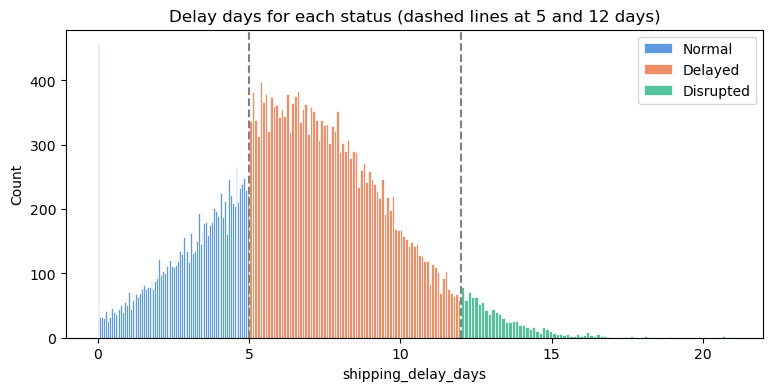

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
for status in status_order:
    sns.histplot(df.loc[df["route_status"] == status, "shipping_delay_days"], bins=80,
                 color=status_colors[status], label=status, ax=ax, edgecolor="white", linewidth=0.5)
ax.axvline(5, color="gray", ls="--")
ax.axvline(12, color="gray", ls="--")
ax.set_title("Delay days for each status (dashed lines at 5 and 12 days)")
ax.legend()
plt.show()

The three colors never overlap. The status is decided **only** by the delay:
- under 5 days → Normal
- 5 to 12 days → Delayed
- 12 or more days → Disrupted

So `shipping_delay_days` is the answer itself, not a clue. If the model gets this column, it just learns these two cutoffs and looks 100% accurate without learning anything useful. We also wouldn't know the delay until the shipment is already late.

**We should not use `shipping_delay_days` as a model input.** The rest of this notebook leaves it out.

In [5]:
numeric_cols = df.select_dtypes("number").columns.drop(["shipping_delay_days", "status_number"]).tolist()
print("Numeric columns left:", len(numeric_cols))

Numeric columns left: 32


## 3. Which Columns Change the Most Between Statuses?
### Correlation with `status_number`
Same idea as in 02, but with one status column instead of three. Positive = higher value goes with a worse status. Negative = higher value goes with a better status.

In [6]:
status_corr = df[numeric_cols].corrwith(df["status_number"]).sort_values(key=abs, ascending=False)
status_corr.round(3).head(10)

geopolitical_risk_score               0.426
container_availability_index         -0.411
port_congestion_index                 0.321
weather_disruption_score              0.291
trade_volume_tonnes                  -0.162
carbon_emissions_tonnes              -0.110
freight_cost_usd                      0.058
natural_gas_price                     0.025
russia_ukraine_war_active            -0.016
origin_logistics_performance_index    0.010
dtype: float64

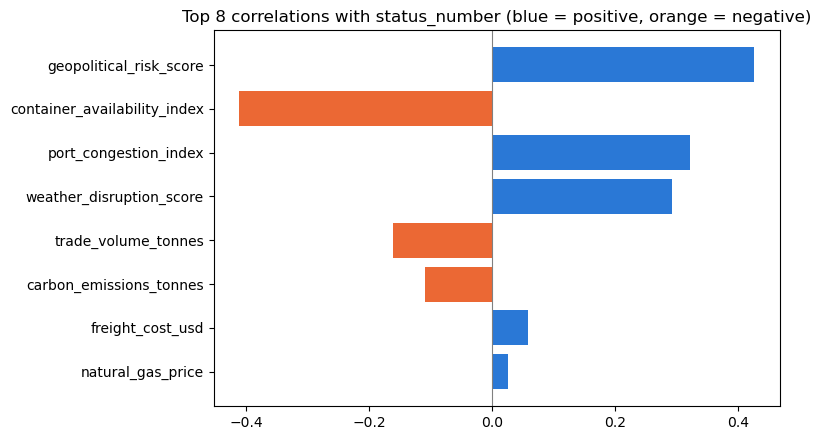

In [7]:
top_corr = status_corr.head(8).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(top_corr.index, top_corr.values,
        color=["#2a78d6" if v > 0 else "#eb6834" for v in top_corr.values])
ax.axvline(0, color="gray", lw=0.8)
ax.set_title("Top 8 correlations with status_number (blue = positive, orange = negative)")
plt.tight_layout()
plt.show()

### Average Value per Status
Correlation is just one number, so here is a simpler check: the average of each top column for Normal, Delayed and Disrupted. If a column matters, the averages should move steadily from Normal to Disrupted.

In [8]:
top_cols = status_corr.head(7).index.tolist()
df.groupby("route_status")[top_cols].mean().loc[status_order].T.round(1)

route_status,Normal,Delayed,Disrupted
geopolitical_risk_score,34.3,58.0,81.9
container_availability_index,83.2,71.5,61.7
port_congestion_index,37.2,55.0,72.0
weather_disruption_score,39.2,55.4,70.8
trade_volume_tonnes,20934.6,17943.6,14792.5
carbon_emissions_tonnes,7168.5,6144.2,5342.3
freight_cost_usd,3963.1,4079.1,4611.4


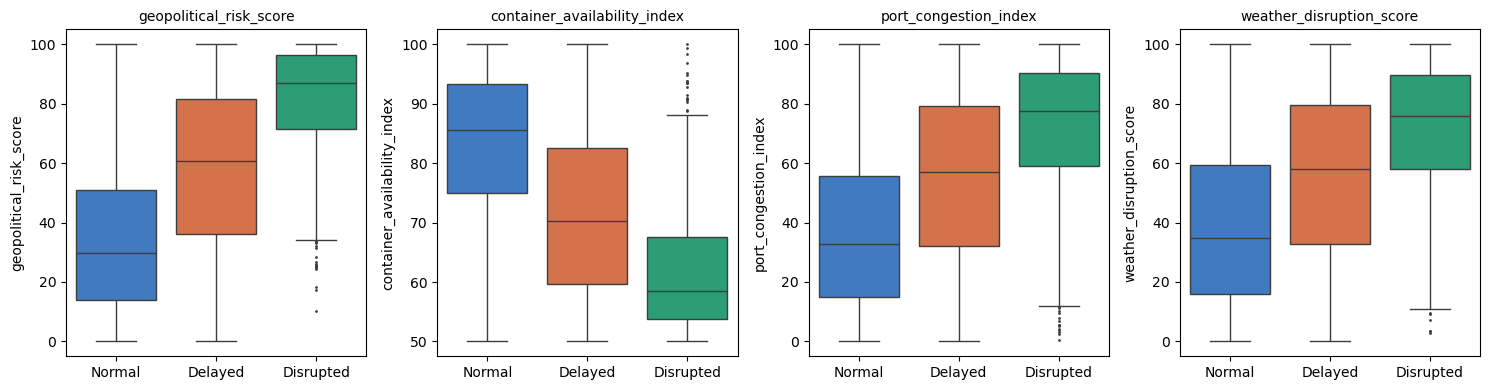

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, col in zip(axes, top_cols[:4]):
    sns.boxplot(data=df, x="route_status", y=col, order=status_order, hue="route_status",
                palette=status_colors, ax=ax, fliersize=1, legend=False)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

The same 4 columns from 02 stand out clearly (now without `shipping_delay_days`):
- `geopolitical_risk_score`: goes **up** as status gets worse
- `container_availability_index`: goes **down** as status gets worse
- `port_congestion_index`: goes **up**
- `weather_disruption_score`: goes **up**

`trade_volume_tonnes`, `carbon_emissions_tonnes` and `freight_cost_usd` have a small effect. Everything else is close to 0.

## 4. Do the Text Columns Matter?
In 02 we one-hot encoded the text columns (country, shipping method, route type...) and they all had correlations around 0.01. Another way to check: if a text column matters, the **percent** of Normal / Delayed / Disrupted should be different for each value.

In [10]:
(pd.crosstab(df["shipping_method"], df["route_status"], normalize="index") * 100).round(1)[status_order]

route_status,Normal,Delayed,Disrupted
shipping_method,,,
Air,33.4,63.7,3.0
Rail,32.2,64.6,3.1
Road,33.5,62.8,3.7
Sea,32.4,64.6,3.0


In [11]:
(pd.crosstab(df["origin_country"], df["route_status"], normalize="index") * 100).round(1)[status_order]

route_status,Normal,Delayed,Disrupted
origin_country,,,
Australia,33.2,63.7,3.1
Brazil,31.1,66.1,2.8
Canada,32.4,64.5,3.2
China,32.8,64.0,3.1
France,33.0,64.1,2.9
Germany,32.5,64.2,3.3
India,32.4,64.0,3.6
Japan,32.4,64.5,3.0
United Kingdom,33.9,62.7,3.4


In [12]:
# Same check for every text column: how far apart are the highest and lowest "Normal" percent?
text_cols = ["route_id", "origin_country", "destination_country", "shipping_method", "trade_route_type",
             "origin_region", "destination_region", "origin_income_group", "destination_income_group"]

normal_spread = {}
for col in text_cols:
    normal_percent = (df["route_status"] == "Normal").groupby(df[col]).mean() * 100
    normal_spread[col] = normal_percent.max() - normal_percent.min()

pd.Series(normal_spread, name="gap in Normal % (max - min)").round(1).sort_values(ascending=False)

route_id                    7.0
origin_country              2.9
destination_country         2.6
origin_region               2.3
destination_region          1.8
origin_income_group         1.8
destination_income_group    1.3
shipping_method             1.2
trade_route_type            1.2
Name: gap in Normal % (max - min), dtype: float64

The percents are almost the same for every country, shipping method and route type: about 33% Normal, 64% Delayed, 3% Disrupted everywhere. Most columns are within 1–3 points (`route_id` is a bit wider because each route only has 626 weeks, which is just random noise).

So **the text columns don't tell us much about the status**. When we build the model, we should try it both with and without the one-hot columns and see if they help at all.

## 5. Are Any Columns Copies of Each Other?
If two columns are almost the same, the model gets the same information twice. This doesn't add anything and can make the results harder to explain. Here we look for column pairs with a correlation above 0.8 (or below -0.8).

In [13]:
feature_corr = df[numeric_cols].corr()

pairs = []
for i, col_a in enumerate(numeric_cols):
    for col_b in numeric_cols[i + 1:]:
        value = feature_corr.loc[col_a, col_b]
        if abs(value) > 0.8:
            pairs.append((col_a, col_b, round(value, 3)))

pd.DataFrame(pairs, columns=["column_a", "column_b", "correlation"]).sort_values("correlation", key=abs, ascending=False)

,column_a,column_b,correlation
1,container_availability_index,geopolitical_risk_score,-0.986
0,distance_km,freight_cost_usd,0.968
2,origin_active_event_count,origin_active_event_risk,0.933
3,destination_active_event_count,destination_active_event_risk,0.931


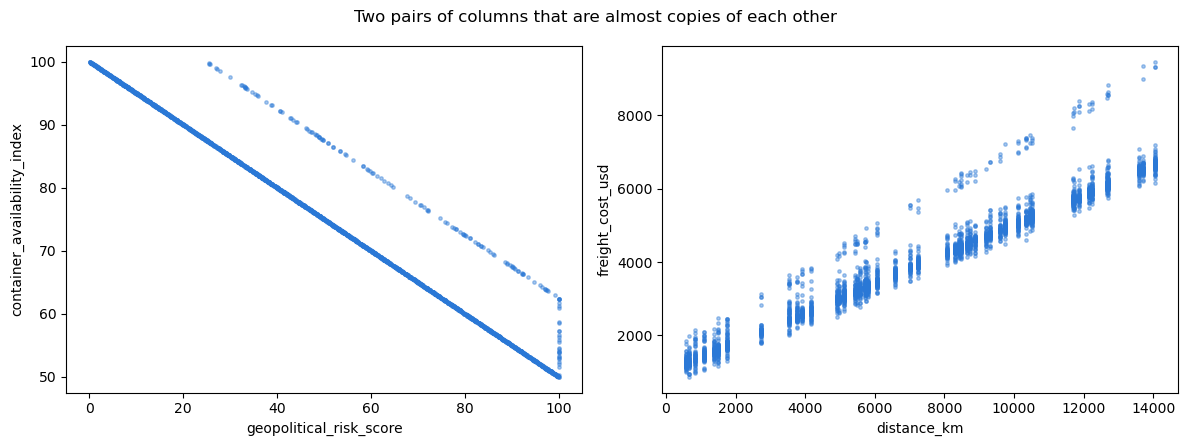

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sample = df.sample(3000, random_state=42)
axes[0].scatter(sample["geopolitical_risk_score"], sample["container_availability_index"], s=6, alpha=0.4, color="#2a78d6")
axes[0].set_xlabel("geopolitical_risk_score")
axes[0].set_ylabel("container_availability_index")
axes[1].scatter(sample["distance_km"], sample["freight_cost_usd"], s=6, alpha=0.4, color="#2a78d6")
axes[1].set_xlabel("distance_km")
axes[1].set_ylabel("freight_cost_usd")
fig.suptitle("Two pairs of columns that are almost copies of each other")
plt.tight_layout()
plt.show()

Some pairs are nearly copies:
- `geopolitical_risk_score` and `container_availability_index` (about -0.99): when risk goes up, availability goes down by the same amount. This is why they were #1 and #2 in section 3: **it's really the same signal counted twice.**
- `distance_km` and `freight_cost_usd`: longer routes cost more.
- The active event count and active event risk columns (from 01) also move together.

For each pair, we can probably keep just one column.

## 6. Can Last Week Predict This Week?
Everything above compares numbers and status **from the same week**. But to warn about a disruption *before* it happens, we'd need last week's numbers to say something about this week.

`.shift(1)` moves each route's values down one row, so each week gets the value from the week before.

In [15]:
lag_check = pd.DataFrame({
    "same week": df[top_cols[:4]].corrwith(df["status_number"]),
    "1 week before": df.groupby("route_id")[top_cols[:4]].shift(1).corrwith(df["status_number"]),
    "2 weeks before": df.groupby("route_id")[top_cols[:4]].shift(2).corrwith(df["status_number"]),
})
lag_check.round(3)

,same week,1 week before,2 weeks before
geopolitical_risk_score,0.426,0.022,0.015
container_availability_index,-0.411,-0.002,0.004
port_congestion_index,0.321,0.011,-0.002
weather_disruption_score,0.291,0.000,-0.003


In [16]:
last_week_status = df.groupby("route_id")["status_number"].shift(1)
print("Correlation between last week's status and this week's status:", round(last_week_status.corr(df["status_number"]), 3))

Correlation between last week's status and this week's status: 0.017


As soon as we use last week's numbers, the correlation drops to about 0. Last week's status doesn't predict this week's status either. Every week is basically independent.

This means our model can answer: *"Given this week's risk, congestion and weather numbers, is this week Normal, Delayed or Disrupted?"* It **can't** predict future weeks, so adding "last week" columns won't help.

## 7. Summary
**What we learned**
1. `shipping_delay_days` is the answer itself (under 5 = Normal, 5–12 = Delayed, 12+ = Disrupted). Don't use it as an input.
2. The columns that matter most are `geopolitical_risk_score`, `container_availability_index`, `port_congestion_index` and `weather_disruption_score`.
3. `geopolitical_risk_score` and `container_availability_index` are almost copies of each other, so it's really 3 strong signals, not 4.
4. The text columns (country, shipping method, route type...) barely change the status.
5. Last week's data doesn't help predict this week.

**Next steps for the baseline model (03)**
- Remove `shipping_delay_days` from the inputs.
- Start with the main numeric columns: `geopolitical_risk_score`, `port_congestion_index`, `weather_disruption_score`, plus `trade_volume_tonnes` and `freight_cost_usd`.
- Try it with and without `container_availability_index` and the one-hot text columns, and see if the score changes.
- Reminder from 01: Disrupted jumps from ~2% to ~12% in 2026, so if 2026 is the test set, check the scores for each status separately, not just overall accuracy.